# Algoritmos de clustering

En el presente notebook se presentan los algoritmos ***k-means*** y la **agrupación jerárquica aglomerativa** (HCA, por sus siglas en inglés). Ambos tienen como objetivo agrupar los elementos de un conjunto de datos con base en características semejantes; sin embargo, su enfoque y funcionamiento difieren significativamente.

**Importante**

Dado que los algoritmos calculan distancias entre los elementos, es fundamental que:
1. Los datos sean numéricos.
2. Los datos estén normalizados o estandarizados, para evitar que una variable con mayor escala domine el cálculo de distancias.

## Métricas para algoritmos no supervisados

Las métricas que se emplean en los algoritmos no supervisados miden diversos aspectos de los clusters; no obstante, la principal métrica es *silhouette_score*, la cual mide la distancia intra-cluster y la distancia con el cluster más cercano. El resto de métricas requieren conocer la clase a la que pertenece cada punto, así se pueden conocer aspectos como la homogeneidad, la completitud, el ajuste, entre otros.

La librería *sklearn* cuenta con las siguientes métricas:
* ***silhouette_score***
* ***homogeneity_score***. Indica si todos los elementos de un cluster pertenecen a la misma clase.
* ***completeness_score***. Indica si todos los elementos de una clase pertenecen al mismo cluster.
* ***v_measure_score***. Es la media armonica entre homogeneidad y completitud, su formula es:
$$
  v = \frac{(1+\beta)*homogeneity*completeness}{(\beta*homogeneity+completeness)}
$$
* ***adjusted_rand_score***. Mide la similitud entre 2 clustering ajustados por el azar, mediante comparaciones de pares de puntos y su asignación a un cluster.
* ***adjusted_mutual_info_score***. Mide la similitud entre 2 clusteres ajustados por el azar, empleando teoría de la información y entropía.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import pi
from sklearn.datasets import load_iris, load_wine

from sklearn.metrics import silhouette_score
from sklearn.metrics import homogeneity_score, completeness_score
from sklearn.metrics import v_measure_score, adjusted_rand_score
from sklearn.metrics import adjusted_mutual_info_score

In [2]:
from sklearn.cluster import KMeans

np.random.seed(5)

X_whole, y_whole = load_iris(return_X_y=True)

In [3]:
from sklearn.preprocessing import MinMaxScaler
scaler_data = MinMaxScaler()
X_train = scaler_data.fit_transform(X_whole)

y = y_whole

## ***k-means***

*k-means* es un algoritmo de agrupamiento que asigna cada muestra del conjunto de datos a uno de los **k** grupos o *clusters*. Por lo tanto, el valor de **k** debe definirse previamente, ya que constituye un parámetro inicial del algoritmo.

El objetivo principal de *k-means* es **minimizar** la variabilidad dentro de cada *cluster* (es decir, que los elementos de un grupo sean lo más similares posible entre sí) y **maximizar** la diferencia entre los *clusters* (que los grupos sean lo más distintos posible entre ellos).

Para alcanzar este objetivo, el algoritmo realiza un proceso iterativo que alterna entre la asignación de elementos al *cluster* más cercano (basado en la distancia al **centroide**) y la actualización de los centroides. Este proceso se repite hasta que ya no se producen cambios significativos en la asignación de los elementos, es decir, cuando el algoritmo converge.

### Método de sklearn

Parámetros:

* n_clusters: número de clusters, por default 8
* init: método de inicialización
  * 'k-means++' distribución de probabilidad empírica
  * 'random'
* n_init: número de veces que se ejecuta el algoritmo de k-means con diferentes semillas de centroide. Por default 'auto'.
* max_iter: Máximo número de iteraciones

In [4]:
lst_metrics = []
lst_columns = ["k", "Silhouette Coefficient", "Homogeneity", "Completeness", "V-measure",
              "Adjusted Rand Index", "Adjusted Mutual Information"]

## K-means con 4 clusters

In [5]:
k4_means = KMeans(n_clusters=4)
k4_means.fit(X_train)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [6]:
print(f'Centroides:\n{k4_means.cluster_centers_}')
print(f'Etiquetas: {k4_means.labels_}')

Centroides:
[[0.29960317 0.7827381  0.08595642 0.07440476]
 [0.66773504 0.44310897 0.7571708  0.78205128]
 [0.41203704 0.27690972 0.55896893 0.52083333]
 [0.1558642  0.52199074 0.07532957 0.05555556]]
Etiquetas: [3 3 3 3 3 0 3 3 3 3 0 3 3 3 0 0 0 3 0 0 3 0 3 3 3 3 3 3 3 3 3 3 0 0 3 3 0
 3 3 3 3 3 3 3 0 3 0 3 0 3 1 1 1 2 2 2 1 2 2 2 2 2 2 2 2 1 2 2 2 2 1 2 2 2
 2 2 1 1 2 2 2 2 2 2 2 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 1 1 1 2 1 1 1 1
 1 1 2 1 1 1 1 1 2 1 2 1 1 1 1 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 2 1 1 1 1 1
 1 1]


In [7]:
cluster_labels_k4 = k4_means.predict(X_train)
silhouette_avg = silhouette_score(X_train, cluster_labels_k4)
print(f"For n_clusters = 4, the average silhouette score is: {silhouette_avg}")
print(f"For n_clusters = 4, the score is: {k4_means.score(X_train)}")

For n_clusters = 4, the average silhouette score is: 0.3849684476558358
For n_clusters = 4, the score is: -6.2244377198323715


In [8]:
lst_metrics_k4 =[]
lst_metrics_k4.append(4)
lst_metrics_k4.append(silhouette_score(X_train, cluster_labels_k4))
lst_metrics_k4.append(homogeneity_score(y, cluster_labels_k4))
lst_metrics_k4.append(completeness_score(y, cluster_labels_k4))
lst_metrics_k4.append(v_measure_score(y, cluster_labels_k4))
lst_metrics_k4.append(adjusted_rand_score(y, cluster_labels_k4))
lst_metrics_k4.append(adjusted_mutual_info_score(y, cluster_labels_k4))

lst_metrics.append(lst_metrics_k4)

## K-means con 3 clusters

In [9]:
k3_means = KMeans(n_clusters=3, init="random")
k3_means.fit(X_train)

,n_clusters,3
,init,'random'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [10]:
print(f'Centroides:\n{k3_means.cluster_centers_}')
print(f'Etiquetas: {k3_means.labels_}')

Centroides:
[[0.19611111 0.595      0.07830508 0.06083333]
 [0.70726496 0.4508547  0.79704476 0.82478632]
 [0.44125683 0.30737705 0.57571548 0.54918033]]
Etiquetas: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 1 1 1 2 1 1 1 1
 1 1 2 1 1 1 1 1 2 1 2 1 2 1 1 2 2 1 1 1 1 1 2 2 1 1 1 2 1 1 1 2 1 1 1 2 1
 1 2]


In [11]:
cluster_labels_k3 = k3_means.predict(X_train)
silhouette_avg = silhouette_score(X_train, cluster_labels_k3)
print(f"For n_clusters = 3, the average silhouette score is: {silhouette_avg}")
print(f"For n_clusters = 3, the score is: {k3_means.score(X_train)}")

For n_clusters = 3, the average silhouette score is: 0.5047687565398589
For n_clusters = 3, the score is: -6.982216473785235


In [12]:
lst_metrics_k3 =[]
lst_metrics_k3.append(3)
lst_metrics_k3.append(silhouette_score(X_train, cluster_labels_k3))
lst_metrics_k3.append(homogeneity_score(y, cluster_labels_k3))
lst_metrics_k3.append(completeness_score(y, cluster_labels_k3))
lst_metrics_k3.append(v_measure_score(y, cluster_labels_k3))
lst_metrics_k3.append(adjusted_rand_score(y, cluster_labels_k3))
lst_metrics_k3.append(adjusted_mutual_info_score(y, cluster_labels_k3))

lst_metrics.append(lst_metrics_k3)

## K-means con 2 clusters

In [13]:
k2_means = KMeans(n_clusters=2)
k2_means.fit(X_train)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [14]:
print(f'Centroides:\n{k2_means.cluster_centers_}')
print(f'Etiquetas: {k2_means.labels_}')

Centroides:
[[0.19611111 0.595      0.07830508 0.06083333]
 [0.545      0.36333333 0.6620339  0.65666667]]
Etiquetas: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]


In [15]:
cluster_labels_k2 = k2_means.predict(X_train)
silhouette_avg = silhouette_score(X_train, cluster_labels_k2)
print(f"For n_clusters = 2, the average silhouette score is: {silhouette_avg}")
print(f"For n_clusters = 2, the score is: {k2_means.score(X_train)}")

For n_clusters = 2, the average silhouette score is: 0.6300471284354711
For n_clusters = 2, the score is: -12.127790750538194


In [16]:
lst_metrics_k2 =[]
lst_metrics_k2.append(2)
lst_metrics_k2.append(silhouette_score(X_train, cluster_labels_k2))
lst_metrics_k2.append(homogeneity_score(y, cluster_labels_k2))
lst_metrics_k2.append(completeness_score(y, cluster_labels_k2))
lst_metrics_k2.append(v_measure_score(y, cluster_labels_k2))
lst_metrics_k2.append(adjusted_rand_score(y, cluster_labels_k2))
lst_metrics_k2.append(adjusted_mutual_info_score(y, cluster_labels_k2))

lst_metrics.append(lst_metrics_k2)

In [17]:
df_metrics = pd.DataFrame(columns=lst_columns, data=lst_metrics)

In [18]:
df_metrics.round(2)

,k,Silhouette Coefficient,Homogeneity,Completeness,V-measure,Adjusted Rand Index,Adjusted Mutual Information
0,4,0.38,0.71,0.61,0.66,0.58,0.65
1,3,0.50,0.74,0.75,0.74,0.72,0.74
2,2,0.63,0.58,1.00,0.73,0.57,0.73


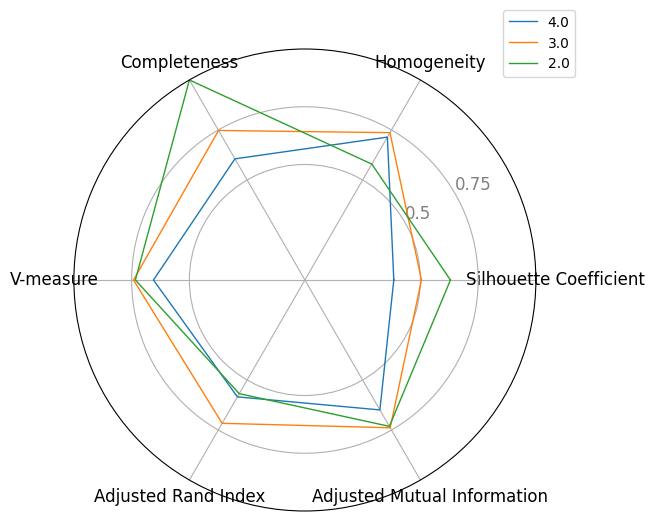

In [19]:
# obtain df information
categories = list(df_metrics)[1:]
values = df_metrics.mean().values.flatten().tolist()
values += values[:1] # repeat the first value to close the circular graph
angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

# define plot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 6),
                        subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='black', size=12)
plt.yticks(np.arange(0.5, 1.0, 0.25), ['0.5', '0.75'], #, '1.0', '1.5'],
           color='grey', size=12)
plt.ylim(0, 1)
ax.set_rlabel_position(30)

# draw radar-chart:
for i in range(len(df_metrics)):
    val_c1 = df_metrics.loc[i].drop('k').values.flatten().tolist()
    val_c1 += val_c1[:1]
    ax.plot(angles, val_c1, linewidth=1, linestyle='solid',
            label=df_metrics.loc[i]["k"])

# add legent and show plot
plt.legend(bbox_to_anchor=(1.1, 1.1))
plt.show()

### Graficas

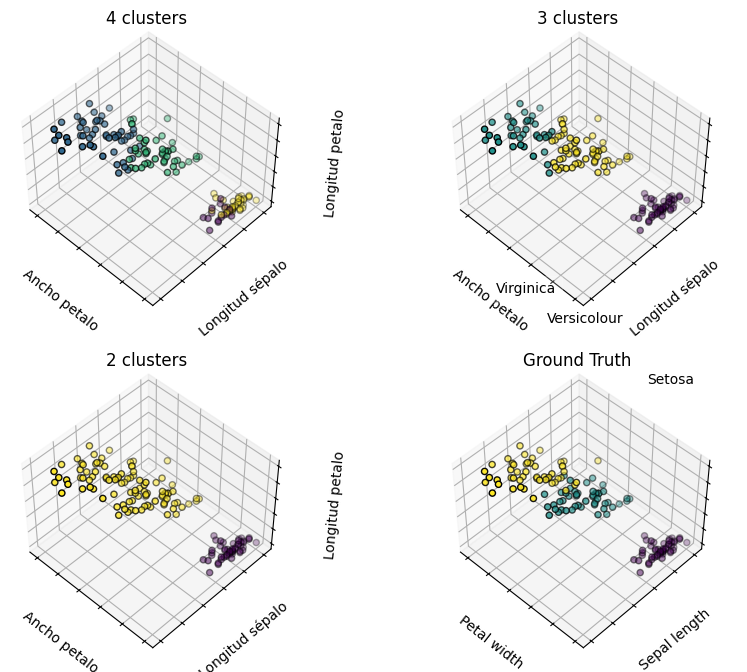

In [21]:
estimators = [
    ("k_means_iris_4", k4_means),
    ("k_means_iris_3_random", k3_means),
    ("k_means_iris_2", k2_means),
]

fig = plt.figure(figsize=(10, 8))
titles = ["4 clusters", "3 clusters", "2 clusters"]
for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d", elev=48, azim=134)
    labels = est.labels_

    ax.scatter(X_train[:, 3], X_train[:, 0], X_train[:, 2], c=labels.astype(float), edgecolor="k")

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel("Ancho petalo")
    ax.set_ylabel("Longitud sépalo")
    ax.set_zlabel("Longitud petalo")
    ax.set_title(title)

# Plot the ground truth
ax = fig.add_subplot(2, 2, 4, projection="3d", elev=48, azim=134)

for name, label in [("Setosa", 0), ("Versicolour", 1), ("Virginica", 2)]:
    ax.text3D(
        X_train[y == label, 3].mean(),
        X_train[y == label, 0].mean(),
        X_train[y == label, 2].mean() + 2,
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.2, edgecolor="w", facecolor="w"),
    )

ax.scatter(X_train[:, 3], X_train[:, 0], X_train[:, 2], c=y, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("Petal width")
ax.set_ylabel("Sepal length")
ax.set_zlabel("Petal length")
ax.set_title("Ground Truth")

plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()

## Obtención del valor para k

Para elegir el número óptimo de clústers se emplea el ***método de Elbow*** también conocido como el método del codo. Para ello se calcula el modelo de clasificación variando el número de clústers, posteriormente se grafica el scores de todos los modelos donde se busca donde la línea es menos suave o cambia de manera abrupta, es decir, donde se hace un "*codo*", ese es el número óptimo de clústers.

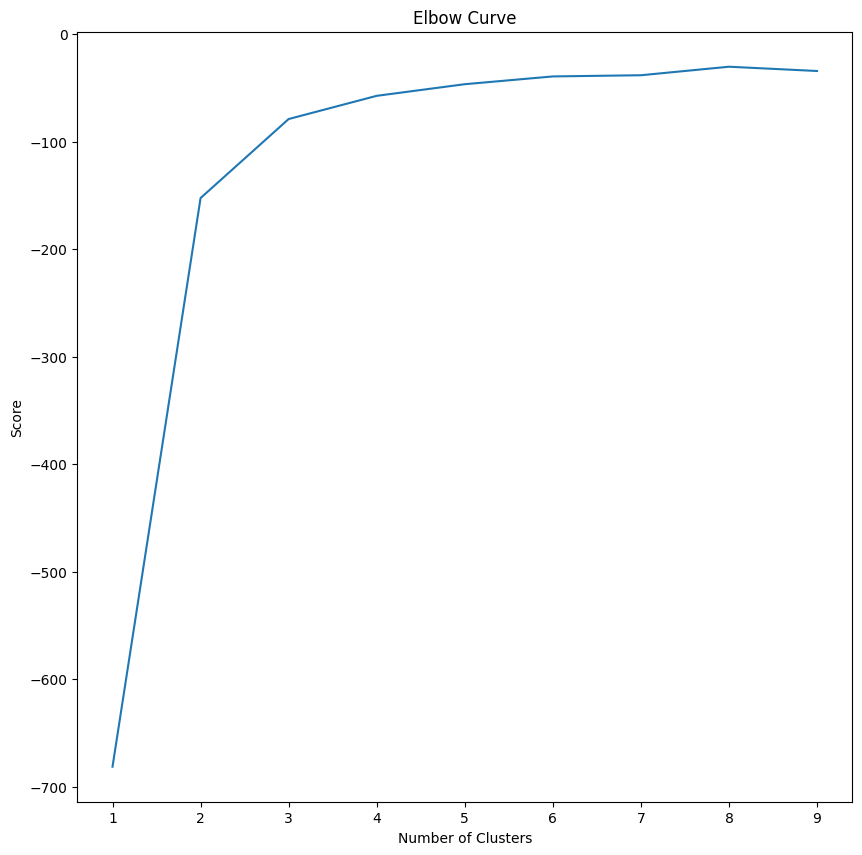

In [ ]:
Nc = range(1, 10)
kmeans = [KMeans(n_clusters=i) for i in Nc]
kmeans
score = [kmeans[i].fit(X_whole).score(X_whole) for i in range(len(kmeans))]
score
plt.rcParams['figure.figsize'] = (10, 10)
plt.plot(Nc, score)
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()

## **Agrupación jerárquica aglomerativa (HCA)**

La **agrupación jerárquica aglomerativa** no requiere especificar el número de clusters con antelación. En su lugar, construye una jerarquía de agrupamientos que puede visualizarse mediante un **dendrograma**, una estructura en forma de árbol que permite identificar agrupamientos naturales en los datos.

Este algoritmo comienza considerando que cada muestra es un *cluster* individual. Luego, en cada iteración, fusiona los dos *clusters* más cercanos, y repite este proceso hasta que todas las muestras pertenecen a un solo *cluster*.

### Método de sklearn

**AgglomerativeClustering** fusiona de manera recursiva el par de conglomerados que aumenta minimamente una determinada distancia de enlazamiento.

Sus parámetros son:
 * **n_clusters**, es un valor entero que representa el número de conglomerados. Debe ser *None* si el parámetro *distance_threshold* no es *None*.
 * **distance_threshold** es un valor real que representa el umbral de distancia de enlazamiento por encima del cual los conglemerados no se fusionarán. Si no es *None*, n_clusters debe ser *None* y *compute_full_tree* debe ser *True*.
 * **compute_full_tree** es un valor booleano que indica si se detiene de manera anticipada la construcción del árbol en n_clusters. Lo anterior es útil para reducir el tiempo de cálculo en aquellos casos cuando el número de conglomerados no es pequeño comparado con el número de muestras. Esta opción sólo es útil cuando se especifica una matriz de conectividad (parámetro *connectivity*) También puede tomar el valor de "auto”, el cual es por default, sin embargo, cuando *distance_threshold* es diferente de *None* es equivalente a *True*, este valor se asume cuando *n_clusters* es inferior al máximo entre 100 o 0.02 * n_samples.

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

In [ ]:
def plot_dendrogram(model, **kwargs):
    # Creación de una matriz de vinculación, para graficar el dendograma
    # Creación de los conteos de las muestras por debajo de cada nodo
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Gráfico correspondiente al Dendograma
    dendrogram(linkage_matrix, **kwargs)

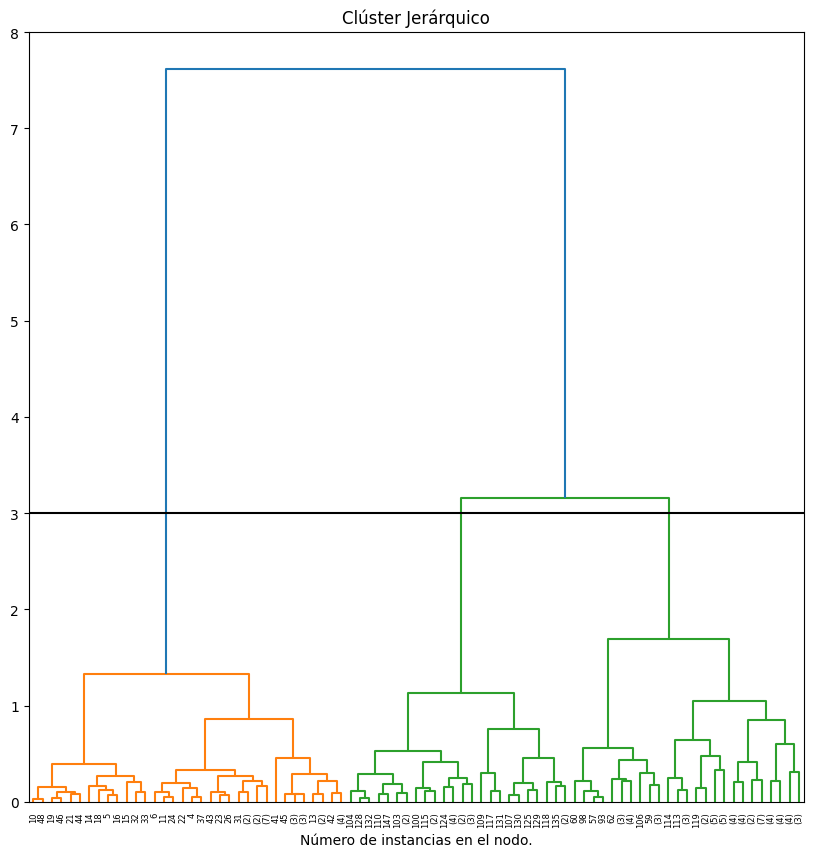

In [ ]:
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(X_train)
plt.title("Clúster Jerárquico")
plt.rcParams['figure.figsize'] = (10, 10)
# Gráfico de niveles del dendograma
plot_dendrogram(model, truncate_mode="level", p=6)
plt.xlabel("Número de instancias en el nodo.")
# Corte del dendograma en el número max_d
plt.axhline(y=3, c='k')
plt.show()